## Исследование одноcлойных НС на примере моделирования булевых выражений

Цель работы - исследовать функционирование простейшей НС на базе нейрона с нелинейной функцией активации и обучить её по правилу Видроу-Хоффа

In [65]:
import numpy as np
import pandas as pd
from itertools import product, combinations
import matplotlib.pyplot as plt
from typing import List, Tuple

In [66]:
def func(x0: int, x1: int, x2: int, x3: int, x4: int) -> int:
    return int(not(((x1 or x2) and x3) or (x3 and x4)))


def get_truth_table(func):
    values = list(list(x) + [func(*x)] for x in product([0, 1], repeat=func.__code__.co_argcount))
    df = pd.DataFrame(values, columns=(list(func.__code__.co_varnames) + [func.__name__]))
    df = df[df['x0'] == 1].reset_index(drop=True)
    return df

### Таблица истинности функции

In [67]:
truth_table = get_truth_table(func)
truth_table

,x0,x1,x2,x3,x4,func
0,1,0,0,0,0,1
1,1,0,0,0,1,1
2,1,0,0,1,0,1
3,1,0,0,1,1,0
4,1,0,1,0,0,1
5,1,0,1,0,1,1
6,1,0,1,1,0,0
7,1,0,1,1,1,0
8,1,1,0,0,0,1
9,1,1,0,0,1,1


### Класс персептрона

In [68]:
class Perceptron:
    def __init__(
        self,
        n_inputs: int = 5,
        learning_rate: float = 0.3,
        activation_type: str = 'threshold'
    ):
        self.weights = np.zeros(n_inputs)
        self.learning_rate = learning_rate
        self.activation_type = activation_type
        self.delta_history = []
        self.weights_history = []
        self.predictions_history = []
        self.targets = None
        self.last_epoch = -1


    def get_net(self, X_i: np.ndarray) -> float:
        return np.sum(self.weights * X_i)


    def activate(self, net: float) -> float:
        if self.activation_type == 'threshold':
            return 1.0 if net >= 0.0 else 0.0
        elif self.activation_type == 'logistic':
            return 0.5 * (np.tanh(net) + 1)
        else:
            raise ValueError(f'Неизвестная функция активации -> {self.activation_type}')


    def predict(self, X_i: np.ndarray) -> int:
        net = self.get_net(X_i)
        out = self.activate(net)
        if self.activation_type == 'logistic':
            return 1 if out >= 0.5 else 0
        return int(out)


    def predict_batch(self, X: np.ndarray) -> np.ndarray:
        return np.array([self.predict(x) for x in X])


    def train_step(self, X_i: np.ndarray, y_i: int) -> float:
        predicted_y = self.predict(X_i)
        delta = y_i - predicted_y
        if self.activation_type == 'threshold':
            delta_weights = self.learning_rate * delta * X_i
        else:
            net = self.get_net(X_i)
            out = self.activate(net)
            df_net = 2 * out * (1 - out)
            delta_weights = self.learning_rate * delta * df_net * X_i
        self.weights += delta_weights
        return abs(delta)


    def train_epoch(self, X: np.ndarray, y: np.ndarray) -> float:
        total_delta = 0
        for i in range(len(X)):
            delta = self.train_step(X[i], y[i])
            total_delta += delta
        return total_delta


    def train(self, X: np.ndarray, y: np.ndarray, max_epochs: int = 1000) -> List[float]:
        self.targets = y.copy()
        for epoch in range(max_epochs):
            self.weights_history.append(self.weights.copy())
            predictions = self.predict_batch(X)
            self.predictions_history.append(predictions.copy())
            total_delta = self.train_epoch(X, y)
            self.delta_history.append(total_delta)
            if total_delta == 0:
                self.last_epoch = epoch + 1
                break
        else:
            print(f'Достигнуто максимальное число эпох -> {max_epochs}')
        return self.delta_history
    
    
    def print_training_info(self, X: np.ndarray) -> None:
        print(f"\n{'='*50}")
        print(f'Информация о перцептроне с {"пороговой" if self.activation_type == "threshold" else "логистической"} ФА')
        print(f'Скорость обучения -> {self.learning_rate}')
        print(f'Образцов -> {len(X)}')
        print(f'Веса -> {self.weights}')
        if self.last_epoch > -1:
            print(f'Обучение завершено на эпохе -> {self.last_epoch}')
        else:
            print(f'Обучение ещё не проводилось или не было успешно завершено')
        print(f"{'='*50}\n")


    def get_truth_table_results(self, X: np.ndarray) -> pd.DataFrame:
        df = pd.DataFrame(X, columns=['x0', 'x1', 'x2', 'x3', 'x4'])
        df['target'] = self.targets
        df['predicted'] = self.predict_batch(X)
        df['match'] = df['target'] == df['predicted']
        return df
    
    
    def get_weights_history(self) -> pd.DataFrame:
        df = pd.DataFrame(self.weights_history, 
                        columns=['w0', 'w1', 'w2', 'w3', 'w4']
                        )
        df['epoch'] = range(1, len(df) + 1)
        df['E(epoch)'] = self.delta_history
        df = df[['epoch', 'w0', 'w1', 'w2', 'w3', 'w4', 'E(epoch)']]
        return df

### Динамика обучения модели

In [69]:
def get_plot(threshold_deltas: List[float], logistic_deltas: List[float]) -> None:
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 10))
    last_epoch_threshold = len(threshold_deltas)
    last_epoch_logistic = len(logistic_deltas)
    
    all_epochs_threshold = list(range(1, last_epoch_threshold + 1))
    ax1_ticks = all_epochs_threshold[::max(1, len(all_epochs_threshold) // 10)]
    if last_epoch_threshold not in ax1_ticks:
        ax1_ticks = sorted(ax1_ticks + [last_epoch_threshold])

    all_epochs_logistic = list(range(1, last_epoch_logistic + 1))
    ax2_ticks = all_epochs_logistic[::max(1, len(all_epochs_logistic) // 10)]
    if last_epoch_logistic not in ax2_ticks:
        ax2_ticks = sorted(ax2_ticks + [last_epoch_logistic])
    
    ax1.plot(
        range(1, last_epoch_threshold + 1),
        threshold_deltas,
        marker='o',
        label='Пороговая ФА'
        )
    ax1.scatter(last_epoch_threshold, threshold_deltas[-1], 
                color='red', s=100, zorder=5, label='Последняя эпоха')
    ax1.axvline(x=last_epoch_threshold, color='red', linestyle='--', 
                alpha=0.7, linewidth=1)
    ax1.set_xlabel('Эпоха k', fontsize=14)
    ax1.set_ylabel('Суммарная ошибка E(k)', fontsize=14)
    ax1.set_title('Динамика обучения перцептрона (Пороговая ФА)', fontsize=16, pad=10)
    ax1.set_xticks(ax1_ticks)
    ax1.legend(loc='upper right')
    ax1.grid(True, alpha=0.5, linestyle='--')
    ax1.set_ylim(bottom=0)
    
    ax2.plot(
        range(1, last_epoch_logistic + 1),
        logistic_deltas,
        marker='o',
        label='Логистическая ФА'
        )
    ax2.scatter(last_epoch_logistic, logistic_deltas[-1], 
                color='red', s=100, zorder=5, label='Последняя эпоха')
    ax2.axvline(x=last_epoch_logistic, color='red', linestyle='--', 
                alpha=0.7, linewidth=1)
    ax2.set_xticks(ax2_ticks)
    ax2.set_xlabel('Эпоха k', fontsize=14)
    ax2.set_ylabel('Суммарная ошибка E(k)', fontsize=14)
    ax2.set_title('Динамика обучения перцептрона (Логистическая ФА)', fontsize=16, pad=10)
    ax2.legend(loc='upper right')
    ax2.grid(True, alpha=0.5, linestyle='--')
    ax2.set_ylim(bottom=0)
    
    plt.tight_layout()
    plt.show()

### Тренируем перцептроны с пороговой и логистической ФА


Информация о перцептроне с пороговой ФА
Скорость обучения -> 0.3
Образцов -> 16
Веса -> [ 1.5 -0.3 -0.3 -1.5 -0.3]
Обучение завершено на эпохе -> 20

    x0  x1  x2  x3  x4  target  predicted  match
0    1   0   0   0   0       1          1   True
1    1   0   0   0   1       1          1   True
2    1   0   0   1   0       1          1   True
3    1   0   0   1   1       0          0   True
4    1   0   1   0   0       1          1   True
5    1   0   1   0   1       1          1   True
6    1   0   1   1   0       0          0   True
7    1   0   1   1   1       0          0   True
8    1   1   0   0   0       1          1   True
9    1   1   0   0   1       1          1   True
10   1   1   0   1   0       0          0   True
11   1   1   0   1   1       0          0   True
12   1   1   1   0   0       1          1   True
13   1   1   1   0   1       1          1   True
14   1   1   1   1   0       0          0   True
15   1   1   1   1   1       0          0   True

    epoch   w0 

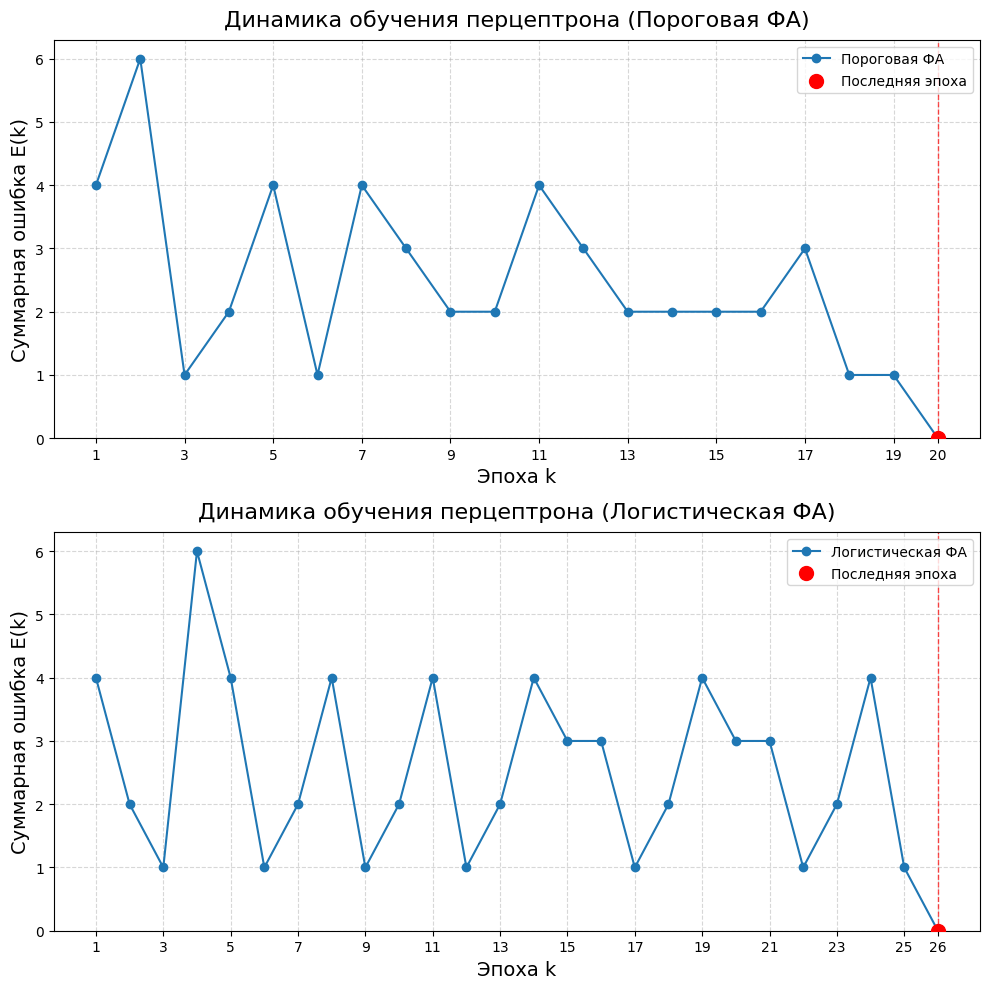

In [70]:
X = np.array(truth_table.drop(columns='func').values.tolist())
y = np.array(truth_table['func'].values.tolist())

threshold_perceptron = Perceptron(activation_type='threshold')
threshold_deltas = threshold_perceptron.train(X, y)
threshold_perceptron.print_training_info(X)
threshold_truth_table = threshold_perceptron.get_truth_table_results(X)
threshold_weights_deltas_history = threshold_perceptron.get_weights_history()
print(f'{threshold_truth_table}\n')
print(threshold_weights_deltas_history)

logistic_perceptron = Perceptron(activation_type='logistic')
logistic_deltas = logistic_perceptron.train(X, y)
logistic_perceptron.print_training_info(X)
logistic_truth_table = logistic_perceptron.get_truth_table_results(X)
logistic_weights_deltas_history = logistic_perceptron.get_weights_history()
print(logistic_truth_table)
print(logistic_weights_deltas_history)

get_plot(threshold_deltas, logistic_deltas)


### Найдем минимальный обучающий вектор

In [71]:
def find_minimal_set(X: np.ndarray, y: np.ndarray, activation_type: str = 'threshold') -> Tuple[Perceptron, pd.DataFrame, List]:
    n_samples = len(X)
    for size in range(3, n_samples + 1):
        for idx in combinations(range(n_samples), size):
            idx = list(idx)
            X_sub = X[idx]
            y_sub = y[idx]
            percep = Perceptron(activation_type=activation_type)
            delta_history = percep.train(X_sub, y_sub)
            y_pred = percep.predict_batch(X)
            delta = np.sum(y != y_pred)
            if delta == 0:
                df = pd.DataFrame(X_sub, columns=['x0', 'x1', 'x2', 'x3', 'x4'])
                df['target'] = y_sub
                return percep, df, delta_history
    print('Не найдено решение')
    return None, None, None


Информация о перцептроне с пороговой ФА
Скорость обучения -> 0.3
Образцов -> 4
Веса -> [ 1.2 -0.3 -0.3 -1.2 -0.3]
Обучение завершено на эпохе -> 16

   x0  x1  x2  x3  x4  target  predicted  match
0   1   0   0   1   0       1          1   True
1   1   0   0   1   1       0          0   True
2   1   1   1   0   1       1          1   True
3   1   1   1   1   0       0          0   True
    epoch   w0   w1   w2   w3   w4  E(epoch)
0       1  0.0  0.0  0.0  0.0  0.0         3
1       2 -0.3  0.0  0.0 -0.6  0.0         1
2       3  0.0  0.0  0.0 -0.3  0.0         4
3       4  0.0  0.0  0.0 -0.6  0.0         4
4       5  0.0  0.0  0.0 -0.9  0.0         1
5       6  0.3  0.0  0.0 -0.6  0.0         2
6       7  0.3  0.0  0.0 -0.6 -0.3         4
7       8  0.3  0.0  0.0 -0.9 -0.3         2
8       9  0.3 -0.3 -0.3 -0.9 -0.3         3
9      10  0.6 -0.3 -0.3 -0.9  0.0         4
10     11  0.6 -0.3 -0.3 -1.2  0.0         3
11     12  0.9  0.0  0.0 -1.2  0.0         2
12     13  0.9  0.0  0.0 

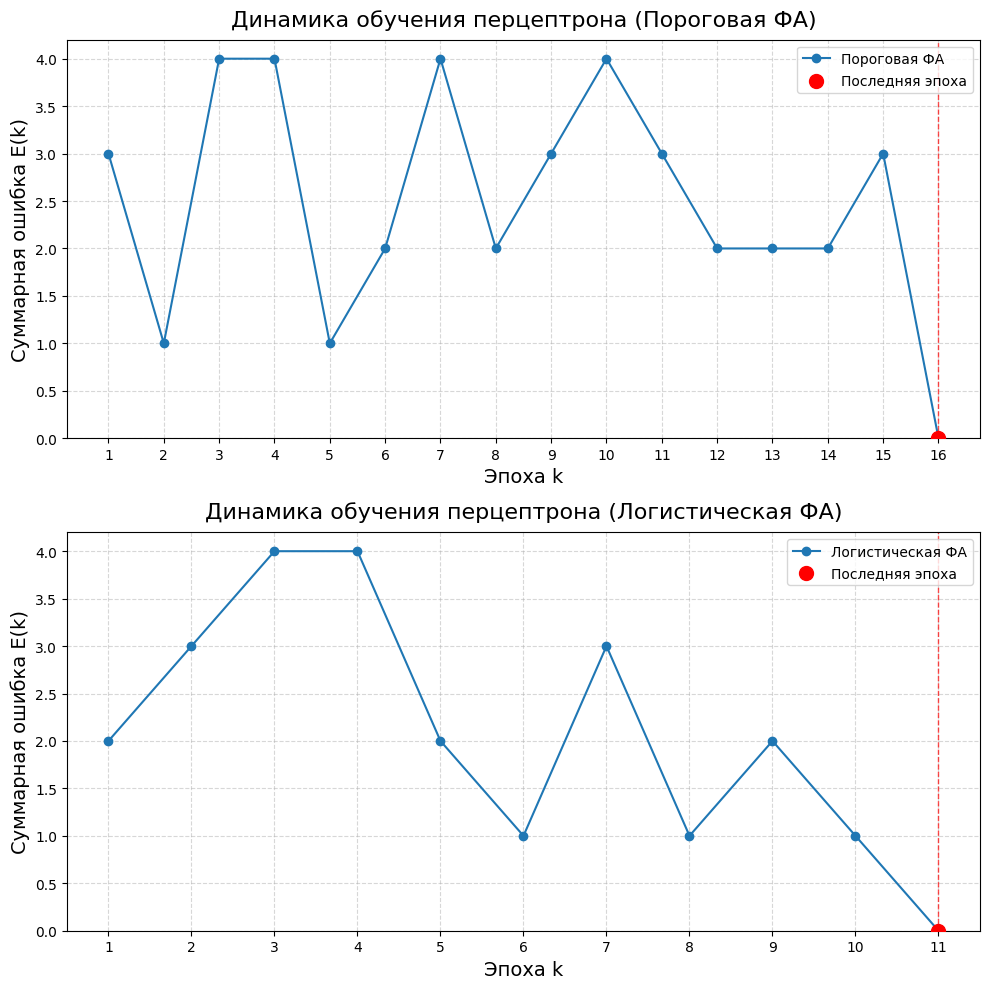

In [72]:
min_threshold_perceptron, min_threshold_df, min_threshold_deltas = find_minimal_set(X, y, activation_type='threshold')
min_logistic_perceptron, min_logistic_df, min_logistic_deltas = find_minimal_set(X, y, activation_type='logistic')

min_threshold_perceptron.print_training_info(min_threshold_df.drop(columns='target').values)
min_threshold_truth_table = min_threshold_perceptron.get_truth_table_results(min_threshold_df.drop(columns='target').values)
min_threshold_weights_deltas_history = min_threshold_perceptron.get_weights_history()
print(min_threshold_truth_table)
print(min_threshold_weights_deltas_history)

min_logistic_perceptron.print_training_info(min_logistic_df.drop(columns='target').values)
min_logistic_truth_table = min_logistic_perceptron.get_truth_table_results(min_logistic_df.drop(columns='target').values)
min_logistic_weights_deltas_history = min_logistic_perceptron.get_weights_history()
print(min_logistic_truth_table)
print(min_logistic_weights_deltas_history)

get_plot(min_threshold_deltas, min_logistic_deltas)